In [7]:
import os
import shutil

dataset_path = "/data/ifthikar/Reserach Paper folder/Dataset"

keep = {"Non-Venomous", "Venomous"}

for item in os.listdir(dataset_path):
    full_path = os.path.join(dataset_path, item)

    if os.path.isdir(full_path) and item not in keep:
        print("Deleting:", item)
        shutil.rmtree(full_path)

print("✅ Dataset cleaned — notebook untouched.")


Deleting: split_copy
Deleting: split_ratio_80_10_10
✅ Dataset cleaned — notebook untouched.


In [9]:
import os

dataset_path = os.path.abspath("./Dataset")
print(dataset_path)


/data/ifthikar/Reserach Paper folder/Dataset


In [10]:

input_folder = "/data/ifthikar/Reserach Paper folder/Dataset"

for folder in ["Venomous", "Non-Venomous"]:
    folder_path = os.path.join(input_folder, folder)

    if os.path.isdir(folder_path):
        files = len([
            f for f in os.listdir(folder_path)
            if os.path.isfile(os.path.join(folder_path, f))
        ])
        
        print(f"{folder}: {files} files")
    else:
        print(f"Folder not found: {folder}")

Venomous: 1110 files
Non-Venomous: 389 files


In [11]:
import os
import shutil
import splitfolders

# ---------------------- PATHS ----------------------
input_folder = "/data/ifthikar/Reserach Paper folder/Dataset"

ratio_output = "/data/ifthikar/Reserach Paper folder/Dataset/split_ratio_80_10_10"

backup_output = "/data/ifthikar/Reserach Paper folder/Dataset/split_copy"


# ---------------------- CLEAN + PREP OUTPUTS ----------------------
for p in [ratio_output, backup_output]:
    if os.path.exists(p):
        shutil.rmtree(p)
    os.makedirs(p, exist_ok=True)

print("\n📁 Output folders ready.")


# ---------------------- DATA CHECK ----------------------
counts = {}
for cls in os.listdir(input_folder):
    path = os.path.join(input_folder, cls)
    if os.path.isdir(path):
        counts[cls] = len([f for f in os.listdir(path) if os.path.isfile(os.path.join(path, f))])

print("\n📌 Class counts:", counts)


# ---------------------- BACKUP ----------------------
shutil.copytree(input_folder, backup_output, dirs_exist_ok=True)
print(f"🛟 Backup created at: {backup_output}")


# ---------------------- SPLIT MODE 1: RATIO (80/10/10) ----------------------
print("\n🔄 Running ratio split...")
splitfolders.ratio(
    input_folder,
    output=ratio_output,
    seed=42,
    ratio=(0.8, 0.1, 0.1),
)

print(f"✅ Ratio split completed at: {ratio_output}")
print("🎉 Done — dataset is now fully prepared!")



📁 Output folders ready.

📌 Class counts: {'Non-Venomous': 389, 'Venomous': 1110, 'split_copy': 0, 'split_ratio_80_10_10': 0}
🛟 Backup created at: /data/ifthikar/Reserach Paper folder/Dataset/split_copy

🔄 Running ratio split...


Copying files: 1499 files [00:06, 244.10 files/s]

✅ Ratio split completed at: /data/ifthikar/Reserach Paper folder/Dataset/split_ratio_80_10_10
🎉 Done — dataset is now fully prepared!


In [18]:
import os

output_folder = "/data/ifthikar/Reserach Paper folder/Dataset/split_ratio_80_10_10"
splits = ["train", "val", "test"]
classes = ["Venomous", "Non-Venomous"]

print("\n📊 Dataset Distribution Summary\n")

for split in splits:
    print(f"\n🔹 {split.upper()} SET")

    split_path = os.path.join(output_folder, split)
    total_split = 0

    for cls in classes:
        cls_path = os.path.join(split_path, cls)

        if os.path.exists(cls_path):
            count = len([f for f in os.listdir(cls_path)
                         if f.lower().endswith(('.png','.jpg','.jpeg'))])
        else:
            count = 0

        total_split += count
        print(f"   {cls}: {count} images")

    print(f"   ➜ Total {split}: {total_split} images")



📊 Dataset Distribution Summary


🔹 TRAIN SET
   Venomous: 851 images
   Non-Venomous: 309 images
   ➜ Total train: 1160 images

🔹 VAL SET
   Venomous: 107 images
   Non-Venomous: 38 images
   ➜ Total val: 145 images

🔹 TEST SET
   Venomous: 106 images
   Non-Venomous: 40 images
   ➜ Total test: 146 images


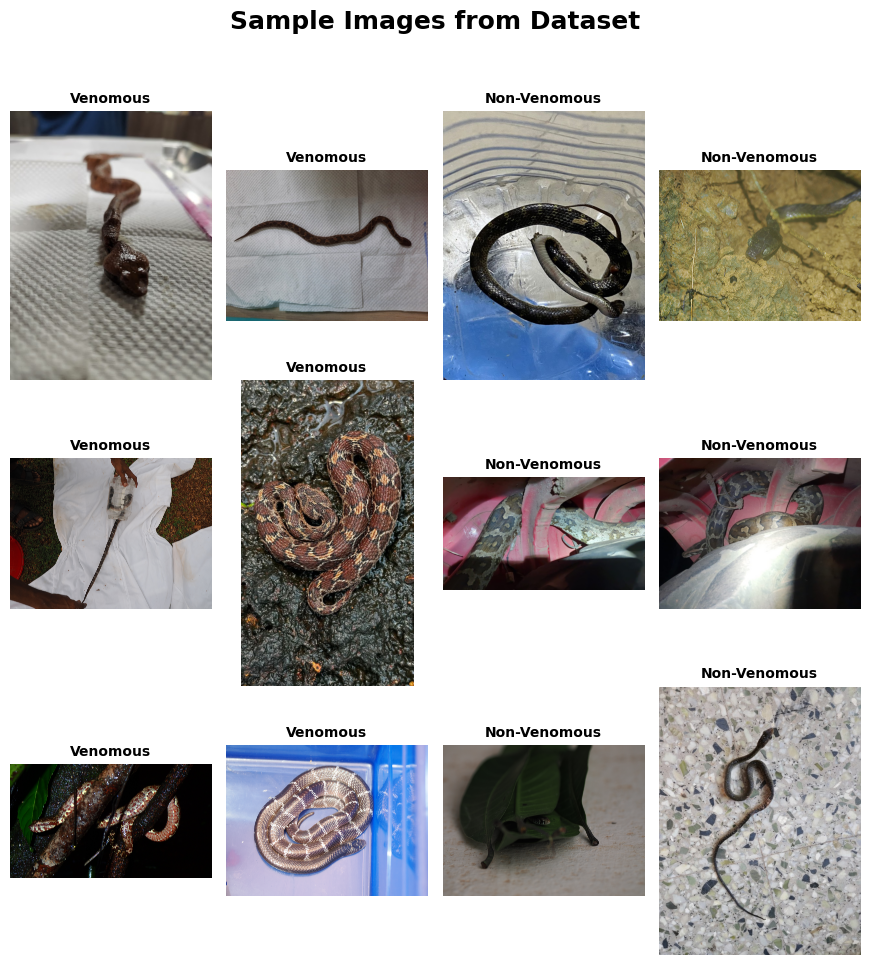

In [13]:
import os
import random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

output_folder = "/data/ifthikar/Reserach Paper folder/Dataset/split_ratio_80_10_10"

splits = ["train", "val", "test"]
classes = ["Venomous", "Non-Venomous"]
images_per_class = 2

rows = len(splits)
cols = len(classes) * images_per_class

fig, axes = plt.subplots(rows, cols,
                         figsize=(cols * 2.2, rows * 3.2))

for r, split in enumerate(splits):
    col_idx = 0

    for cls in classes:
        cls_path = os.path.join(output_folder, split, cls)

        if os.path.exists(cls_path):
            images = [os.path.join(cls_path, f)
                      for f in os.listdir(cls_path)
                      if f.lower().endswith(('.jpg','.jpeg','.png'))]
            selected = random.sample(images, min(images_per_class, len(images)))
        else:
            selected = []

        for img_path in selected:
            ax = axes[r, col_idx]

            try:
                img = mpimg.imread(img_path)
                ax.imshow(img)

                # ONLY class label
                ax.set_title(cls,
                             fontsize=10,
                             fontweight='bold')
            except:
                ax.text(0.5,0.5,"Error",ha='center')

            ax.axis("off")
            col_idx += 1

    # split name on left (clean academic layout)
    axes[r,0].set_ylabel(split.upper(),
                         fontsize=12,
                         fontweight='bold')

fig.suptitle(
    "Sample Images from Dataset",
    fontsize=18,
    fontweight="bold",
    y=1.02
)

plt.tight_layout()
plt.show()


In [14]:
import os
import pandas as pd
from tqdm import tqdm
images = []
labels = []
for i in tqdm(['/data/ifthikar/Reserach Paper folder/Dataset/split_ratio_80_10_10/train','/data/ifthikar/Reserach Paper folder/Dataset/split_ratio_80_10_10/val','/data/ifthikar/Reserach Paper folder/Dataset/split_ratio_80_10_10/test']):
    for subfolder in os.listdir(i):
        subfolder_path = os.path.join(i, subfolder)
        if not os.path.isdir(subfolder_path):
            continue
        for image_filename in os.listdir(subfolder_path):
            image_path = os.path.join(subfolder_path, image_filename)
            images.append(image_path)
            labels.append(subfolder)
df = pd.DataFrame({'image': images, 'label': labels})
df

100%|██████████| 3/3 [00:00<00:00, 393.99it/s]


,image,label
0,/data/ifthikar/Reserach Paper folder/Dataset/s...,Non-Venomous
1,/data/ifthikar/Reserach Paper folder/Dataset/s...,Non-Venomous
2,/data/ifthikar/Reserach Paper folder/Dataset/s...,Non-Venomous
3,/data/ifthikar/Reserach Paper folder/Dataset/s...,Non-Venomous
4,/data/ifthikar/Reserach Paper folder/Dataset/s...,Non-Venomous
...,...,...
1494,/data/ifthikar/Reserach Paper folder/Dataset/s...,Venomous
1495,/data/ifthikar/Reserach Paper folder/Dataset/s...,Venomous
1496,/data/ifthikar/Reserach Paper folder/Dataset/s...,Venomous
1497,/data/ifthikar/Reserach Paper folder/Dataset/s...,Venomous


In [23]:
import os
import shutil
import splitfolders

# ---------------------- PATHS ----------------------
input_folder = "/data/ifthikar/Reserach Paper folder/Dataset"
ratio_output = "/data/ifthikar/Reserach Paper folder/split_ratio_80_10_10"
backup_output = "/data/ifthikar/Reserach Paper folder/split_copy"






# ---------------------- CLEAN + PREP OUTPUTS ----------------------
for p in [ratio_output, fixed_output, backup_output]:
    if os.path.exists(p):
        shutil.rmtree(p)
    os.makedirs(p, exist_ok=True)

print("\n📁 Output folders ready.")


# ---------------------- DATA CHECK ----------------------
counts = {}
for cls in os.listdir(input_folder):
    path = os.path.join(input_folder, cls)
    if os.path.isdir(path):
        counts[cls] = len([f for f in os.listdir(path) if os.path.isfile(os.path.join(path, f))])

print("\n📌 Class counts:", counts)


# ---------------------- BACKUP ----------------------
shutil.copytree(input_folder, backup_output, dirs_exist_ok=True)
print(f"🛟 Backup created at: {backup_output}")


# ---------------------- SPLIT MODE 1: RATIO (80/10/10) ----------------------
print("\n🔄 Running ratio split...")
splitfolders.ratio(
    input_folder,
    output=ratio_output,
    seed=42,
    ratio=(0.8, 0.1, 0.1),
)

print(f"✅ Ratio split completed at: {ratio_output}")

print("🎉 Done — dataset is now fully prepared!")



📁 Output folders ready.

📌 Class counts: {'Non-Venomous': 389, 'Venomous': 1110, 'split_copy': 0, 'split_ratio_80_10_10': 0}
🛟 Backup created at: /data/ifthikar/Reserach Paper folder/split_copy

🔄 Running ratio split...



Copying files: 0 files [00:00, ? files/s]
Copying files: 92 files [00:00, 883.29 files/s]
Copying files: 233 files [00:00, 1168.78 files/s]
Copying files: 370 files [00:00, 1258.15 files/s]
Copying files: 497 files [00:01, 284.87 files/s] 
Copying files: 579 files [00:02, 169.12 files/s]
Copying files: 634 files [00:02, 194.11 files/s]
Copying files: 686 files [00:02, 215.12 files/s]
Copying files: 733 files [00:02, 235.49 files/s]
Copying files: 777 files [00:02, 256.71 files/s]
Copying files: 819 files [00:02, 279.43 files/s]
Copying files: 860 files [00:03, 179.88 files/s]
Copying files: 900 files [00:03, 207.67 files/s]
Copying files: 939 files [00:03, 236.20 files/s]
Copying files: 974 files [00:03, 255.56 files/s]
Copying files: 1023 files [00:03, 304.24 files/s]
Copying files: 1062 files [00:03, 316.70 files/s]
Copying files: 1100 files [00:04, 322.92 files/s]
Copying files: 1137 files [00:05, 72.87 files/s] 
Copying files: 1175 files [00:05, 94.76 files/s]
Copying files: 1220 

✅ Ratio split completed at: /data/ifthikar/Reserach Paper folder/split_ratio_80_10_10
🎉 Done — dataset is now fully prepared!


In [2]:
import os
import shutil
import random

# Path to your dataset
dataset_path = "Dataset"

# Get class folders
classes = ["Non-Venomous", "Venomous"]

# Count images in each class
class_counts = {}
for cls in classes:
    cls_path = os.path.join(dataset_path, cls)
    class_counts[cls] = len([f for f in os.listdir(cls_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])

print("Before oversampling:", class_counts)

# Find the majority class count
max_count = max(class_counts.values())

# Oversample minority class
for cls in classes:
    cls_path = os.path.join(dataset_path, cls)
    files = [f for f in os.listdir(cls_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    
    if len(files) < max_count:
        diff = max_count - len(files)
        print(f"Oversampling {cls} by {diff} images...")
        
        for i in range(diff):
            # Randomly pick an image to duplicate
            file_to_copy = random.choice(files)
            src = os.path.join(cls_path, file_to_copy)
            # Make a new filename to avoid overwriting
            dst = os.path.join(cls_path, f"copy_{i}_{file_to_copy}")
            shutil.copy(src, dst)

# Verify
for cls in classes:
    cls_path = os.path.join(dataset_path, cls)
    class_counts[cls] = len([f for f in os.listdir(cls_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])

print("After oversampling:", class_counts)


Before oversampling: {'Non-Venomous': 387, 'Venomous': 1064}
Oversampling Non-Venomous by 677 images...
After oversampling: {'Non-Venomous': 1064, 'Venomous': 1064}


In [1]:
import os
import shutil
from sklearn.model_selection import train_test_split

# Paths
dataset_path = "Dataset"
output_path = "Dataset_Split"
train_ratio = 0.8
val_ratio = 0.1
test_ratio = 0.1

classes = ["Non-Venomous", "Venomous"]

# Create output directories
for split in ["train", "val", "test"]:
    for cls in classes:
        split_path = os.path.join(output_path, split, cls)
        os.makedirs(split_path, exist_ok=True)

# Split and copy files
for cls in classes:
    cls_path = os.path.join(dataset_path, cls)
    files = [f for f in os.listdir(cls_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

    # First split into train and temp (val+test)
    train_files, temp_files = train_test_split(files, train_size=train_ratio, random_state=42, shuffle=True)
    
    # Now split temp into validation and test
    val_files, test_files = train_test_split(temp_files, test_size=test_ratio/(test_ratio+val_ratio), random_state=42, shuffle=True)
    
    # Copy files
    for f in train_files:
        shutil.copy(os.path.join(cls_path, f), os.path.join(output_path, "train", cls, f))
    for f in val_files:
        shutil.copy(os.path.join(cls_path, f), os.path.join(output_path, "val", cls, f))
    for f in test_files:
        shutil.copy(os.path.join(cls_path, f), os.path.join(output_path, "test", cls, f))

# Verify
for split in ["train", "val", "test"]:
    print(f"\n{split.upper()} set counts:")
    for cls in classes:
        split_cls_path = os.path.join(output_path, split, cls)
        count = len([f for f in os.listdir(split_cls_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
        print(f"{cls}: {count}")



TRAIN set counts:
Non-Venomous: 851
Venomous: 851

VAL set counts:
Non-Venomous: 106
Venomous: 106

TEST set counts:
Non-Venomous: 107
Venomous: 107


Using device: cpu
Train class distribution: Counter({'Non-Venomous': 851, 'Venomous': 851})
Val class distribution: Counter({'Non-Venomous': 106, 'Venomous': 106})
Test class distribution: Counter({'Non-Venomous': 107, 'Venomous': 107})
Class weights: tensor([1., 1.])
Starting training with pretrained MobileViT (dropout=0.4), enhanced aug, and balanced sampling...


100%|██████████| 107/107 [03:54<00:00,  2.19s/it]


Epoch 1/300 - Train Loss: 0.6041, Train Acc: 0.7297, Val Loss: 0.5198, Val Acc: 0.7689


100%|██████████| 107/107 [04:10<00:00,  2.34s/it]


Epoch 2/300 - Train Loss: 0.4421, Train Acc: 0.8467, Val Loss: 0.4380, Val Acc: 0.8538


...

Epoch 14/300 - Train Loss: 0.2413, Train Acc: 0.9824, Val Loss: 0.3453, Val Acc: 0.9434


100%|██████████| 107/107 [03:46<00:00,  2.11s/it]


Epoch 15/300 - Train Loss: 0.2434, Train Acc: 0.9824, Val Loss: 0.3324, Val Acc: 0.9434


100%|██████████| 107/107 [04:14<00:00,  2.38s/it]


Epoch 16/300 - Train Loss: 0.2425, Train Acc: 0.9812, Val Loss: 0.3670, Val Acc: 0.9434
Early stopping at epoch 16
Test accuracy: 0.9252
Test F1-score: 0.9249


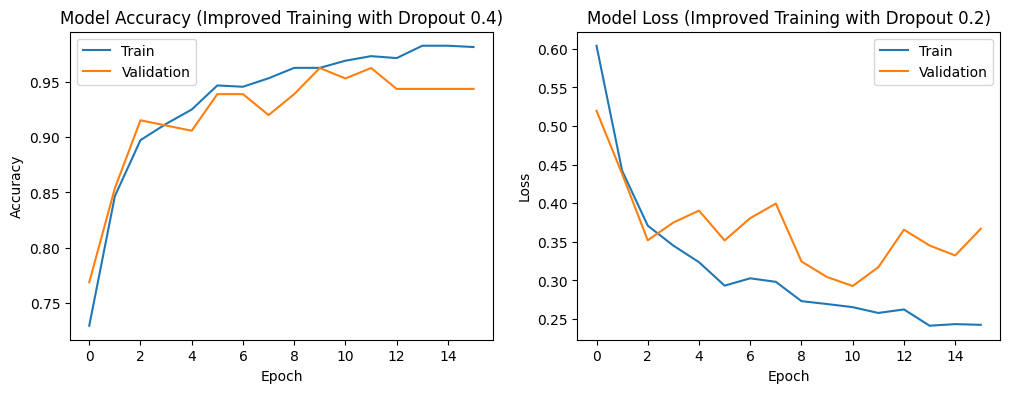

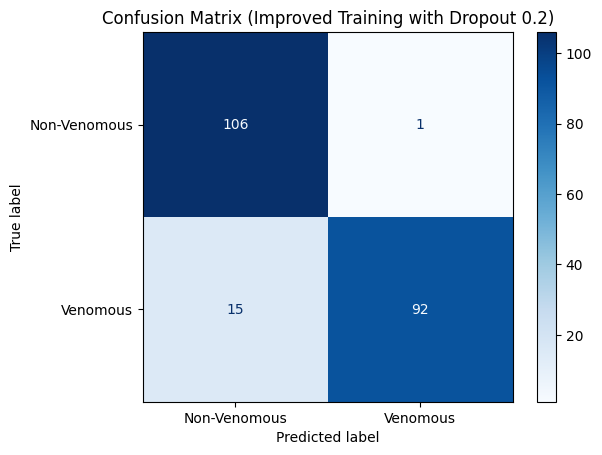

In [2]:
# Installation note: Before running this code, ensure you have the required packages installed:
# pip install torch torchvision torchaudio scikit-learn matplotlib tqdm pandas numpy pillow timm
import os
# Suppress warnings if needed
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'  # Not needed in PyTorch, but kept for consistency
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, WeightedRandomSampler
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, f1_score
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from tqdm import tqdm
import pandas as pd
from collections import Counter
from PIL import Image
import warnings
import timm  # For pretrained models
warnings.filterwarnings('ignore')

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Hyperparameters (tuned for better accuracy)
patch_size = 4  # Kept for compatibility, but using timm model
image_size = 320 #256
batch_size = 16  # Reduced for finer gradients
num_epochs = 300
learning_rate = 1e-4  # 0.0001
dropout_rate = 0.3

# Define data directories (keep as in original)
train_dir = "Dataset_Split/train"
val_dir   = "Dataset_Split/val"
test_dir  = "Dataset_Split/test"

# Function to get class distribution
def get_class_distribution(data_dir):
    labels = []
    for subfolder in os.listdir(data_dir):
        subfolder_path = os.path.join(data_dir, subfolder)
        if os.path.isdir(subfolder_path):
            num_samples = len([f for f in os.listdir(subfolder_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
            labels.extend([subfolder] * num_samples)
    return Counter(labels)

print("Train class distribution:", get_class_distribution(train_dir))
print("Val class distribution:", get_class_distribution(val_dir))
print("Test class distribution:", get_class_distribution(test_dir))

# Enhanced Transforms (stronger augmentation)
train_transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.RandomRotation(45),  # Increased from 30
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.3),
    transforms.RandomAffine(degrees=0, shear=10),  # Added shear
    transforms.RandomPerspective(distortion_scale=0.2, p=0.3),  # Added perspective
    transforms.RandomResizedCrop(image_size, scale=(0.6, 1.2)),  # Wider scale
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4, hue=0.15),  # Increased jitter
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

test_transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Datasets
train_dataset = ImageFolder(train_dir, transform=train_transform)
val_dataset = ImageFolder(val_dir, transform=test_transform)
test_dataset = ImageFolder(test_dir, transform=test_transform)

# Class weights for loss
class_names = train_dataset.classes
y_train = [label for _, label in train_dataset.samples]
class_weights_np = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = torch.tensor(class_weights_np, dtype=torch.float).to(device)
print("Class weights:", class_weights)

# Weighted sampler for class balancing
sample_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
sample_weights = np.array([sample_weights[label] for _, label in train_dataset.samples])
sampler = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)

# DataLoaders (use sampler for train)
train_loader = DataLoader(train_dataset, batch_size=batch_size, sampler=sampler, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)

# Model: Use timm for pretrained MobileViT (corrected model name)
model = timm.create_model('mobilevit_s.cvnets_in1k', pretrained=True, num_classes=2, drop_rate=dropout_rate)
model = model.to(device)


optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1, weight=class_weights)  # With label smoothing
from torch.optim.lr_scheduler import CosineAnnealingLR
scheduler = CosineAnnealingLR(optimizer, T_max=num_epochs)  # Stable scheduler

# Early stopping params
patience = 5  # Increased
best_val_loss = float('inf')
early_stop_counter = 0

# Training history
train_losses, train_accs = [], []
val_losses, val_accs = [], []

print("Starting training with pretrained MobileViT (dropout=0.4), enhanced aug, and balanced sampling...")

for epoch in range(num_epochs):
    # Train
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for inputs, labels in tqdm(train_loader):
        inputs = inputs.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # Gradient clipping
        optimizer.step()
        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    train_loss = running_loss / len(train_loader)
    train_acc = correct / total
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    
    scheduler.step()  # Step per epoch
    
    # Validate
    model.eval()
    val_running_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()
    
    val_loss = val_running_loss / len(val_loader)
    val_acc = val_correct / val_total
    val_losses.append(val_loss)
    val_accs.append(val_acc)
    
    print(f'Epoch {epoch+1}/{num_epochs} - Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}')
    
    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'best_mobilevit_model.pth')
        early_stop_counter = 0
    else:
        early_stop_counter += 1
        if early_stop_counter >= patience:
            print(f'Early stopping at epoch {epoch+1}')
            break

# Load best model
model.load_state_dict(torch.load('best_mobilevit_model.pth', map_location=device))

# Evaluate on test set
model.eval()
test_running_loss, test_correct, test_total = 0.0, 0, 0
all_preds, all_labels = [], []
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        test_running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        test_total += labels.size(0)
        test_correct += (predicted == labels).sum().item()
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_acc = test_correct / test_total
test_f1 = f1_score(all_labels, all_preds, average='weighted')
print(f'Test accuracy: {test_acc:.4f}')
print(f'Test F1-score: {test_f1:.4f}')

# Plot training history
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(train_accs, label='Train')
plt.plot(val_accs, label='Validation')
plt.title('Model Accuracy (Improved Training with Dropout 0.4)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(train_losses, label='Train')
plt.plot(val_losses, label='Validation')
plt.title('Model Loss (Improved Training with Dropout 0.2)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix (Improved Training with Dropout 0.2)')
plt.show()

# Save final model
torch.save(model.state_dict(), 'final_mobilevit_model.pth')

Using device: cpu
Train class distribution: Counter({'Non-Venomous': 851, 'Venomous': 851})
Val   class distribution: Counter({'Non-Venomous': 106, 'Venomous': 106})
Test  class distribution: Counter({'Non-Venomous': 107, 'Venomous': 107})
Classes: ['Non-Venomous', 'Venomous']

Training started: MobileViT-S + Focal Loss + CutMix + Weighted Sampler + OneCycleLR



Epoch 1/100: 100%|██████████| 54/54 [04:34<00:00,  5.08s/it]


Epoch   1/100 | Train Loss: 0.1574  Acc: 0.6992 | Val Loss: 0.1192  Acc: 0.8160  F1: 0.8145  ← best


Epoch 2/100: 100%|██████████| 54/54 [04:39<00:00,  5.18s/it]


Epoch   2/100 | Train Loss: 0.1075  Acc: 0.8331 | Val Loss: 0.0750  Acc: 0.9009  F1: 0.9000  ← best


...

Epoch  16/100 | Train Loss: 0.0890  Acc: 0.8402 | Val Loss: 0.0831  Acc: 0.8726  F1: 0.8711


Epoch 17/100: 100%|██████████| 54/54 [04:30<00:00,  5.00s/it]


Epoch  17/100 | Train Loss: 0.1027  Acc: 0.8443 | Val Loss: 0.1569  Acc: 0.8066  F1: 0.7998


Epoch 18/100: 100%|██████████| 54/54 [04:38<00:00,  5.16s/it]


Epoch  18/100 | Train Loss: 0.0950  Acc: 0.8608 | Val Loss: 0.0950  Acc: 0.8915  F1: 0.8902

Early stopping at epoch 18

══════════════════════════════════════════════════════════════════════
Final Test Results (best model):
  Test Accuracy      : 0.9252
  Test Weighted F1   : 0.9251
══════════════════════════════════════════════════════════════════════


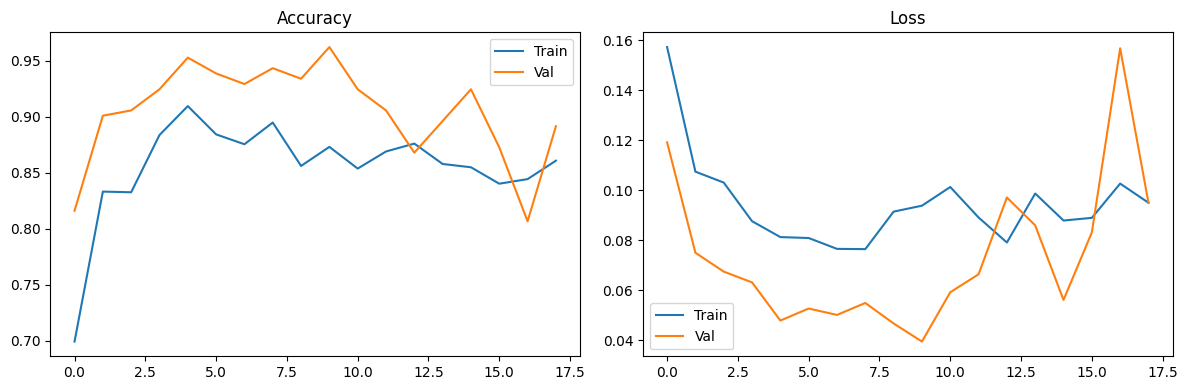

Training finished.


In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, WeightedRandomSampler
import torchvision.transforms as transforms
from collections import Counter
from torchvision.datasets import ImageFolder
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, f1_score
from sklearn.utils.class_weight import compute_class_weight
from tqdm import tqdm
import warnings
import timm
from torch.optim.lr_scheduler import OneCycleLR

warnings.filterwarnings('ignore')

# ────────────────────────────────────────────────────────────────
# Device & Hyperparameters
# ────────────────────────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

image_size = 320
batch_size = 32
val_test_bs = 96
num_epochs = 100
dropout_rate = 0.30
weight_decay = 5e-4

train_dir = "Dataset_Split/train"
val_dir   = "Dataset_Split/val"
test_dir  = "Dataset_Split/test"


# ────────────────────────────────────────────────────────────────
# Focal Loss
# ────────────────────────────────────────────────────────────────
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.75, gamma=1.5, reduction='mean'):
        super().__init__()
        self.alpha = alpha      # > 0.5 to focus more on minority (Non-Venomous)
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = self.alpha * (1 - pt) ** self.gamma * ce_loss
        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        return focal_loss

# ────────────────────────────────────────────────────────────────
# CutMix
# ────────────────────────────────────────────────────────────────
def cutmix_data(x, y, alpha=1.0):
    if alpha <= 0:
        return x, y, y, 1.0
    lam = np.random.beta(alpha, alpha)
    batch_size = x.size(0)
    index = torch.randperm(batch_size).to(x.device)
    W, H = x.size(2), x.size(3)
    cut_rat = np.sqrt(1. - lam)
    cut_w = int(W * cut_rat)
    cut_h = int(H * cut_rat)
    cx = np.random.randint(W)
    cy = np.random.randint(H)
    bbx1 = np.clip(cx - cut_w // 2, 0, W)
    bby1 = np.clip(cy - cut_h // 2, 0, H)
    bbx2 = np.clip(cx + cut_w // 2, 0, W)
    bby2 = np.clip(cy + cut_h // 2, 0, H)
    x[:, :, bbx1:bbx2, bby1:bby2] = x[index, :, bbx1:bbx2, bby1:bby2]
    y_a, y_b = y, y[index]
    lam = 1 - ((bbx2 - bbx1) * (bby2 - bby1) / (W * H))
    return x, y_a, y_b, lam


def cutmix_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

# ────────────────────────────────────────────────────────────────
# Data loading & imbalance handling
# ────────────────────────────────────────────────────────────────
def get_class_distribution(data_dir):
    labels = []
    for subfolder in os.listdir(data_dir):
        subfolder_path = os.path.join(data_dir, subfolder)
        if os.path.isdir(subfolder_path):
            num_samples = len([f for f in os.listdir(subfolder_path)
                               if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
            labels.extend([subfolder] * num_samples)
    return Counter(labels)


print("Train class distribution:", get_class_distribution(train_dir))
print("Val   class distribution:", get_class_distribution(val_dir))
print("Test  class distribution:", get_class_distribution(test_dir))

# Transforms
train_transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.RandomRotation(30),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomAffine(degrees=0, shear=5),
    transforms.RandomPerspective(distortion_scale=0.15, p=0.2),
    transforms.RandomResizedCrop(image_size, scale=(0.75, 1.15)),
    transforms.ColorJitter(0.3, 0.3, 0.3, 0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

test_transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Datasets
train_dataset = ImageFolder(train_dir, transform=train_transform)
val_dataset   = ImageFolder(val_dir,   transform=test_transform)
test_dataset  = ImageFolder(test_dir,  transform=test_transform)

class_names = train_dataset.classes
print("Classes:", class_names)

# Weighted sampler
y_train = [label for _, label in train_dataset.samples]
class_weights_np = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
sample_weights = [class_weights_np[label] for label in y_train]
sampler = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=batch_size,   sampler=sampler,
                          num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=val_test_bs, shuffle=False,
                          num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=val_test_bs, shuffle=False,
                          num_workers=4, pin_memory=True)

# ────────────────────────────────────────────────────────────────
# Model + Optimizer + Scheduler + Criterion
# ────────────────────────────────────────────────────────────────
model = timm.create_model('mobilevit_s.cvnets_in1k', pretrained=True,
                          num_classes=2, drop_rate=dropout_rate)
model = model.to(device)

optimizer = optim.AdamW(model.parameters(), lr=3e-3, weight_decay=weight_decay)
criterion = FocalLoss(alpha=0.75, gamma=1.5)

scheduler = OneCycleLR(
    optimizer,
    max_lr=3e-3,
    epochs=num_epochs,
    steps_per_epoch=len(train_loader),
    pct_start=0.3,
    anneal_strategy='cos',
    div_factor=25.0,
    final_div_factor=1e4,
)

# ────────────────────────────────────────────────────────────────
# Training Loop
# ────────────────────────────────────────────────────────────────
best_val_f1 = 0.0
early_stop_counter = 0
train_losses, val_losses = [], []
train_accs, val_accs = [], []

print("\nTraining started: MobileViT-S + Focal Loss + CutMix + Weighted Sampler + OneCycleLR\n")

for epoch in range(num_epochs):
    # ─── Train ───────────────────────────────────────────────────────
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
        inputs, labels = inputs.to(device), labels.to(device)

        # CutMix 50% probability
        if np.random.rand() < 0.5:
            inputs, targets_a, targets_b, lam = cutmix_data(inputs, labels)
        else:
            targets_a = targets_b = labels
            lam = 1.0

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = cutmix_criterion(criterion, outputs, targets_a, targets_b, lam)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        running_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)           # use original labels for accuracy
        correct += predicted.eq(labels).sum().item()

    train_loss = running_loss / total
    train_acc = correct / total
    train_losses.append(train_loss)
    train_accs.append(train_acc)

    # ─── Validation ──────────────────────────────────────────────────
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    val_loss /= val_total
    val_acc = val_correct / val_total
    val_f1 = f1_score(all_labels, all_preds, average='weighted')

    val_losses.append(val_loss)
    val_accs.append(val_acc)

    # Print progress
    print(f"Epoch {epoch+1:3d}/{num_epochs} | "
          f"Train Loss: {train_loss:.4f}  Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f}  Acc: {val_acc:.4f}  F1: {val_f1:.4f}", end="")

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(model.state_dict(), 'best_mobilevit.pth')
        print("  ← best")
    else:
        print("")
        early_stop_counter += 1
        if early_stop_counter >= 12:
            print(f"\nEarly stopping at epoch {epoch+1}")
            break

# ────────────────────────────────────────────────────────────────
# Load best model & Test
# ────────────────────────────────────────────────────────────────
model.load_state_dict(torch.load('best_mobilevit.pth', map_location=device))
model.eval()

test_correct = 0
test_total = 0
all_preds, all_labels = [], []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = outputs.max(1)
        test_total += labels.size(0)
        test_correct += predicted.eq(labels).sum().item()
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_acc = test_correct / test_total
test_f1 = f1_score(all_labels, all_preds, average='weighted')

print("\n" + "═" * 70)
print(f"Final Test Results (best model):")
print(f"  Test Accuracy      : {test_acc:.4f}")
print(f"  Test Weighted F1   : {test_f1:.4f}")
print("═" * 70)

# ─── Plots ───────────────────────────────────────────────────────
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(train_accs, label='Train')
plt.plot(val_accs, label='Val')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_losses, label='Train')
plt.plot(val_losses, label='Val')
plt.title('Loss')
plt.legend()

plt.tight_layout()
plt.show()

torch.save(model.state_dict(), 'final_mobilevit.pth')
print("Training finished.")

Using device: cpu
Train class distribution: Counter({'Non-Venomous': 851, 'Venomous': 851})
Val class distribution: Counter({'Non-Venomous': 106, 'Venomous': 106})
Test class distribution: Counter({'Non-Venomous': 107, 'Venomous': 107})
Class weights: tensor([1., 1.])
Loading EfficientNet-V2-S model...
Starting training with pretrained EfficientNet-V2-S (dropout=0.3)...
Training for 300 epochs with early stopping (patience=5)


Epoch 1/300 [Val]: 100%|██████████| 14/14 [00:10<00:00,  1.38it/s]


Epoch 1/300 - Train Loss: 3.1610, Train Acc: 0.7127, Val Loss: 1.2446, Val Acc: 0.8491
  → Best model saved (val_loss: 1.2446)


Epoch 2/300 [Val]: 100%|██████████| 14/14 [00:10<00:00,  1.39it/s]


Epoch 2/300 - Train Loss: 1.1118, Train Acc: 0.7979, Val Loss: 0.7356, Val Acc: 0.8585
  → Best model saved (val_loss: 0.7356)


...

Epoch 18/300 - Train Loss: 0.2430, Train Acc: 0.9859, Val Loss: 0.3046, Val Acc: 0.9434


Epoch 19/300 [Val]: 100%|██████████| 14/14 [00:10<00:00,  1.37it/s]


Epoch 19/300 - Train Loss: 0.2456, Train Acc: 0.9835, Val Loss: 0.2969, Val Acc: 0.9623
Early stopping at epoch 19

Loading best model for evaluation...


Testing: 100%|██████████| 14/14 [00:09<00:00,  1.45it/s]



Test Accuracy: 0.9579 (95.79%)
Test F1-Score: 0.9579



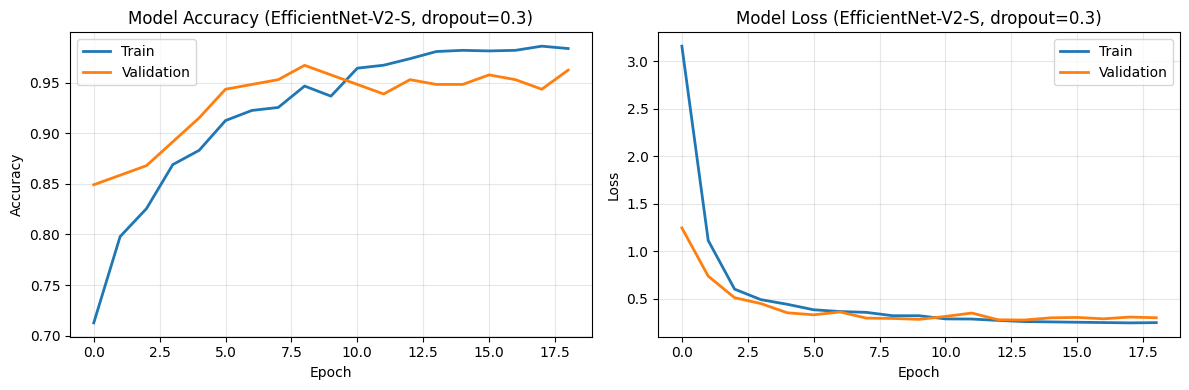

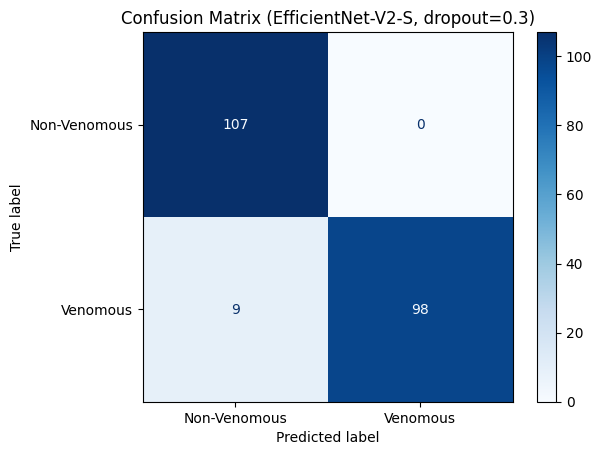


Final model saved as 'final_efficientnetv2_model.pth'
Best model saved as 'best_efficientnetv2_model.pth'
Training complete!


In [4]:
# Installation note: Before running this code, ensure you have the required packages installed:
# pip install torch torchvision torchaudio scikit-learn matplotlib tqdm pandas numpy pillow timm

import os
# Suppress warnings if needed
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, WeightedRandomSampler
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, f1_score
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from tqdm import tqdm
import pandas as pd
from collections import Counter
from PIL import Image
import warnings
import timm  # For pretrained models

warnings.filterwarnings('ignore')

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Hyperparameters (tuned for better accuracy)
image_size = 320  # EfficientNet-V2-S works well with this size
batch_size = 16
num_epochs = 300
learning_rate = 1e-4  # 0.0001
dropout_rate = 0.3

# Define data directories
train_dir = "Dataset_Split/train"
val_dir = "Dataset_Split/val"
test_dir = "Dataset_Split/test"

# Function to get class distribution
def get_class_distribution(data_dir):
    labels = []
    for subfolder in os.listdir(data_dir):
        subfolder_path = os.path.join(data_dir, subfolder)
        if os.path.isdir(subfolder_path):
            num_samples = len([f for f in os.listdir(subfolder_path) 
                             if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
            labels.extend([subfolder] * num_samples)
    return Counter(labels)

print("Train class distribution:", get_class_distribution(train_dir))
print("Val class distribution:", get_class_distribution(val_dir))
print("Test class distribution:", get_class_distribution(test_dir))

# Enhanced Transforms (stronger augmentation)
train_transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.RandomRotation(45),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.3),
    transforms.RandomAffine(degrees=0, shear=10),
    transforms.RandomPerspective(distortion_scale=0.2, p=0.3),
    transforms.RandomResizedCrop(image_size, scale=(0.6, 1.2)),
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4, hue=0.15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

test_transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Datasets
train_dataset = ImageFolder(train_dir, transform=train_transform)
val_dataset = ImageFolder(val_dir, transform=test_transform)
test_dataset = ImageFolder(test_dir, transform=test_transform)

# Class weights for loss
class_names = train_dataset.classes
y_train = [label for _, label in train_dataset.samples]
class_weights_np = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = torch.tensor(class_weights_np, dtype=torch.float).to(device)
print("Class weights:", class_weights)

# Weighted sampler for class balancing
sample_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
sample_weights = np.array([sample_weights[label] for _, label in train_dataset.samples])
sampler = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)

# DataLoaders (use sampler for train)
train_loader = DataLoader(train_dataset, batch_size=batch_size, sampler=sampler, 
                         num_workers=4, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, 
                       num_workers=4, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, 
                        num_workers=4, pin_memory=True)

# Model: Use timm for pretrained EfficientNet-V2-S
print("Loading EfficientNet-V2-S model...")
model = timm.create_model('tf_efficientnetv2_s.in21k_ft_in1k', 
                         pretrained=True, 
                         num_classes=2, 
                         drop_rate=dropout_rate)
model = model.to(device)

# Optimizer and loss
optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1, weight=class_weights)

# Learning rate scheduler
from torch.optim.lr_scheduler import CosineAnnealingLR
scheduler = CosineAnnealingLR(optimizer, T_max=num_epochs)

# Early stopping params
patience = 5
best_val_loss = float('inf')
early_stop_counter = 0

# Training history
train_losses, train_accs = [], []
val_losses, val_accs = [], []

print(f"Starting training with pretrained EfficientNet-V2-S (dropout={dropout_rate})...")
print(f"Training for {num_epochs} epochs with early stopping (patience={patience})")

for epoch in range(num_epochs):
    # Train
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    
    for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]"):
        inputs = inputs.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # Gradient clipping
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    train_loss = running_loss / len(train_loader)
    train_acc = correct / total
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    
    scheduler.step()  # Step per epoch
    
    # Validate
    model.eval()
    val_running_loss, val_correct, val_total = 0.0, 0, 0
    
    with torch.no_grad():
        for inputs, labels in tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Val]"):
            inputs = inputs.to(device)
            labels = labels.to(device)
            
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            val_running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()
    
    val_loss = val_running_loss / len(val_loader)
    val_acc = val_correct / val_total
    val_losses.append(val_loss)
    val_accs.append(val_acc)
    
    print(f'Epoch {epoch+1}/{num_epochs} - Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, '
          f'Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}')
    
    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'best_efficientnetv2_model.pth')
        print(f"  → Best model saved (val_loss: {val_loss:.4f})")
        early_stop_counter = 0
    else:
        early_stop_counter += 1
        if early_stop_counter >= patience:
            print(f'Early stopping at epoch {epoch+1}')
            break

# Load best model
print("\nLoading best model for evaluation...")
model.load_state_dict(torch.load('best_efficientnetv2_model.pth', map_location=device))

# Evaluate on test set
model.eval()
test_running_loss, test_correct, test_total = 0.0, 0, 0
all_preds, all_labels = [], []

with torch.no_grad():
    for inputs, labels in tqdm(test_loader, desc="Testing"):
        inputs = inputs.to(device)
        labels = labels.to(device)
        
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        
        test_running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        test_total += labels.size(0)
        test_correct += (predicted == labels).sum().item()
        
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_acc = test_correct / test_total
test_f1 = f1_score(all_labels, all_preds, average='weighted')

print(f'\n{"="*50}')
print(f'Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)')
print(f'Test F1-Score: {test_f1:.4f}')
print(f'{"="*50}\n')

# Plot training history
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(train_accs, label='Train', linewidth=2)
plt.plot(val_accs, label='Validation', linewidth=2)
plt.title(f'Model Accuracy (EfficientNet-V2-S, dropout={dropout_rate})')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(train_losses, label='Train', linewidth=2)
plt.plot(val_losses, label='Validation', linewidth=2)
plt.title(f'Model Loss (EfficientNet-V2-S, dropout={dropout_rate})')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history_efficientnetv2.png', dpi=300, bbox_inches='tight')
plt.show()

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues)
plt.title(f'Confusion Matrix (EfficientNet-V2-S, dropout={dropout_rate})')
plt.savefig('confusion_matrix_efficientnetv2.png', dpi=300, bbox_inches='tight')
plt.show()

# Save final model
torch.save(model.state_dict(), 'final_efficientnetv2_model.pth')
print("\nFinal model saved as 'final_efficientnetv2_model.pth'")
print("Best model saved as 'best_efficientnetv2_model.pth'")
print("Training complete!")

Using device: cpu
Train class distribution: Counter({'Non-Venomous': 851, 'Venomous': 851})
Val class distribution: Counter({'Non-Venomous': 106, 'Venomous': 106})
Test class distribution: Counter({'Non-Venomous': 107, 'Venomous': 107})
Class weights: tensor([1., 1.])
Loading ConvNeXt-Tiny model...
Starting training with pretrained ConvNeXt-Tiny (dropout=0.3)...
Training for 300 epochs with early stopping (patience=5)


Epoch 1/300 [Val]: 100%|██████████| 7/7 [00:37<00:00,  5.37s/it]


Epoch 1/300 - Train Loss: 0.6822, Train Acc: 0.6698, Val Loss: 0.5647, Val Acc: 0.6698
 → Best model saved (val_loss: 0.5647)


Epoch 2/300 [Val]: 100%|██████████| 7/7 [00:41<00:00,  5.90s/it]


Epoch 2/300 - Train Loss: 0.4471, Train Acc: 0.8378, Val Loss: 0.5411, Val Acc: 0.8349
 → Best model saved (val_loss: 0.5411)


...

Epoch 16/300 - Train Loss: 0.2386, Train Acc: 0.9788, Val Loss: 0.3220, Val Acc: 0.9528


Epoch 17/300 [Val]: 100%|██████████| 7/7 [00:37<00:00,  5.32s/it]


Epoch 17/300 - Train Loss: 0.2280, Train Acc: 0.9835, Val Loss: 0.4245, Val Acc: 0.8962
Early stopping at epoch 17

Loading best model for evaluation...


Testing: 100%|██████████| 7/7 [00:32<00:00,  4.67s/it]



Test Accuracy: 0.9533 (95.33%)
Test F1-Score: 0.9532



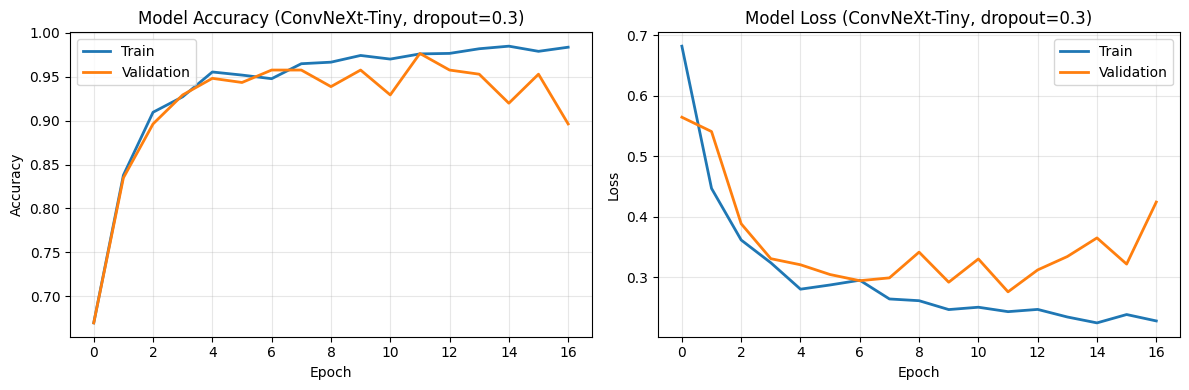

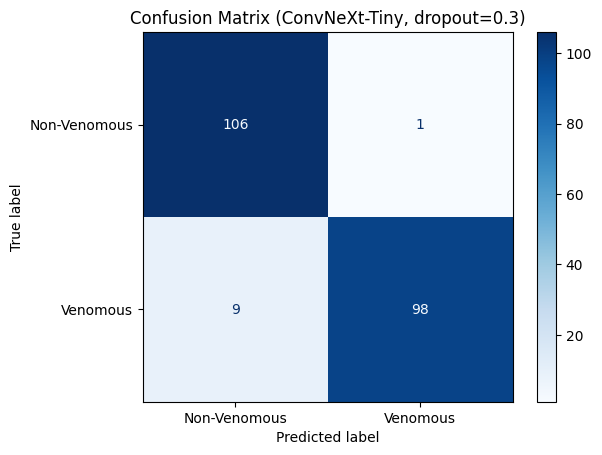


Final model saved as 'final_convnext_tiny_model.pth'
Best model saved as 'best_convnext_tiny_model.pth'
Training complete!


In [3]:
# Installation note: Before running this code, ensure you have the required packages installed:
# pip install torch torchvision torchaudio scikit-learn matplotlib tqdm pandas numpy pillow timm

import os
# Suppress warnings if needed
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, WeightedRandomSampler
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, f1_score
from sklearn.utils.class_weight import compute_class_weight
from tqdm import tqdm
from collections import Counter
import warnings
import timm  # For pretrained models

warnings.filterwarnings('ignore')

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Hyperparameters (kept the same)
image_size = 320
batch_size = 32
num_epochs = 300
learning_rate = 1e-4  # 0.0001
dropout_rate = 0.3

# Define data directories
train_dir = "Dataset_Split/train"
val_dir   = "Dataset_Split/val"
test_dir  = "Dataset_Split/test"

# Function to get class distribution
def get_class_distribution(data_dir):
    labels = []
    for subfolder in os.listdir(data_dir):
        subfolder_path = os.path.join(data_dir, subfolder)
        if os.path.isdir(subfolder_path):
            num_samples = len([f for f in os.listdir(subfolder_path)
                               if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
            labels.extend([subfolder] * num_samples)
    return Counter(labels)

print("Train class distribution:", get_class_distribution(train_dir))
print("Val class distribution:", get_class_distribution(val_dir))
print("Test class distribution:", get_class_distribution(test_dir))

# Enhanced Transforms (kept the same)
train_transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.RandomRotation(45),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.3),
    transforms.RandomAffine(degrees=0, shear=10),
    transforms.RandomPerspective(distortion_scale=0.2, p=0.3),
    transforms.RandomResizedCrop(image_size, scale=(0.6, 1.2)),
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4, hue=0.15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

test_transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Datasets
train_dataset = ImageFolder(train_dir, transform=train_transform)
val_dataset   = ImageFolder(val_dir,   transform=test_transform)
test_dataset  = ImageFolder(test_dir,  transform=test_transform)

# Class weights for loss
class_names = train_dataset.classes
y_train = [label for _, label in train_dataset.samples]
class_weights_np = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = torch.tensor(class_weights_np, dtype=torch.float).to(device)
print("Class weights:", class_weights)

# Weighted sampler for class balancing
sample_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
sample_weights = np.array([sample_weights[label] for _, label in train_dataset.samples])
sampler = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, sampler=sampler,
                          num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False,
                          num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False,
                          num_workers=4, pin_memory=True)

# ────────────────────────────────────────────────────────────────
# Model: Changed to convnext_tiny
# ────────────────────────────────────────────────────────────────
print("Loading ConvNeXt-Tiny model...")
model = timm.create_model('convnext_tiny',
                          pretrained=True,
                          num_classes=2,
                          drop_rate=dropout_rate)
model = model.to(device)

# Optimizer and loss (unchanged)
optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1, weight=class_weights)

# Learning rate scheduler (unchanged)
from torch.optim.lr_scheduler import CosineAnnealingLR
scheduler = CosineAnnealingLR(optimizer, T_max=num_epochs)

# Early stopping params (unchanged)
patience = 5
best_val_loss = float('inf')
early_stop_counter = 0

# Training history
train_losses, train_accs = [], []
val_losses, val_accs = [], []

print(f"Starting training with pretrained ConvNeXt-Tiny (dropout={dropout_rate})...")
print(f"Training for {num_epochs} epochs with early stopping (patience={patience})")

for epoch in range(num_epochs):
    # Train
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]"):
        inputs = inputs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # Gradient clipping
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc = correct / total
    train_losses.append(train_loss)
    train_accs.append(train_acc)

    scheduler.step()  # Step per epoch

    # Validate
    model.eval()
    val_running_loss, val_correct, val_total = 0.0, 0, 0

    with torch.no_grad():
        for inputs, labels in tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Val]"):
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            val_running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_loss = val_running_loss / len(val_loader)
    val_acc = val_correct / val_total
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    print(f'Epoch {epoch+1}/{num_epochs} - Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, '
          f'Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}')

    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'best_convnext_tiny_model.pth')
        print(f" → Best model saved (val_loss: {val_loss:.4f})")
        early_stop_counter = 0
    else:
        early_stop_counter += 1
        if early_stop_counter >= patience:
            print(f'Early stopping at epoch {epoch+1}')
            break

# Load best model
print("\nLoading best model for evaluation...")
model.load_state_dict(torch.load('best_convnext_tiny_model.pth', map_location=device))

# Evaluate on test set
model.eval()
test_running_loss, test_correct, test_total = 0.0, 0, 0
all_preds, all_labels = [], []

with torch.no_grad():
    for inputs, labels in tqdm(test_loader, desc="Testing"):
        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = model(inputs)
        loss = criterion(outputs, labels)

        test_running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        test_total += labels.size(0)
        test_correct += (predicted == labels).sum().item()

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_acc = test_correct / test_total
test_f1 = f1_score(all_labels, all_preds, average='weighted')

print(f'\n{"="*50}')
print(f'Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)')
print(f'Test F1-Score: {test_f1:.4f}')
print(f'{"="*50}\n')

# Plot training history
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(train_accs, label='Train', linewidth=2)
plt.plot(val_accs, label='Validation', linewidth=2)
plt.title(f'Model Accuracy (ConvNeXt-Tiny, dropout={dropout_rate})')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(train_losses, label='Train', linewidth=2)
plt.plot(val_losses, label='Validation', linewidth=2)
plt.title(f'Model Loss (ConvNeXt-Tiny, dropout={dropout_rate})')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history_convnext_tiny.png', dpi=300, bbox_inches='tight')
plt.show()

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues)
plt.title(f'Confusion Matrix (ConvNeXt-Tiny, dropout={dropout_rate})')
plt.savefig('confusion_matrix_convnext_tiny.png', dpi=300, bbox_inches='tight')
plt.show()

# Save final model
torch.save(model.state_dict(), 'final_convnext_tiny_model.pth')

print("\nFinal model saved as 'final_convnext_tiny_model.pth'")
print("Best model saved as 'best_convnext_tiny_model.pth'")
print("Training complete!")

/home/ifthikar/ifthikarenv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cpu
Train class distribution: Counter({'Non-Venomous': 851, 'Venomous': 851})
Val class distribution: Counter({'Non-Venomous': 106, 'Venomous': 106})
Test class distribution: Counter({'Non-Venomous': 107, 'Venomous': 107})
Class weights: tensor([1., 1.])
Loading ResNeXt-50 (32x4d) model...
Starting training with pretrained ResNeXt-50_32x4d (dropout=0.3)...
Training for 300 epochs with early stopping (patience=5)


Epoch 1/300 [Val]: 100%|██████████| 7/7 [00:55<00:00,  7.96s/it]


Epoch 1/300 - Train Loss: 0.6551, Train Acc: 0.6792, Val Loss: 0.5958, Val Acc: 0.7877
 → Best model saved (val_loss: 0.5958)


Epoch 2/300 [Val]: 100%|██████████| 7/7 [00:55<00:00,  7.95s/it]


...

Epoch 13/300 - Train Loss: 0.2329, Train Acc: 0.9865, Val Loss: 0.2868, Val Acc: 0.9575


Epoch 14/300 [Val]: 100%|██████████| 7/7 [00:57<00:00,  8.17s/it]


Epoch 14/300 - Train Loss: 0.2391, Train Acc: 0.9824, Val Loss: 0.2537, Val Acc: 0.9811
Early stopping at epoch 14

Loading best model for evaluation...


Testing: 100%|██████████| 7/7 [00:50<00:00,  7.29s/it]



Test Accuracy: 0.9579 (95.79%)
Test F1-Score: 0.9579



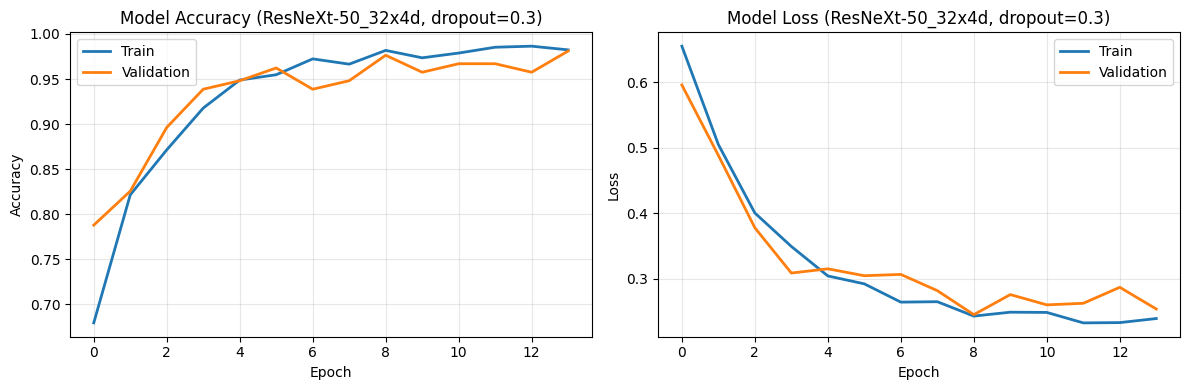

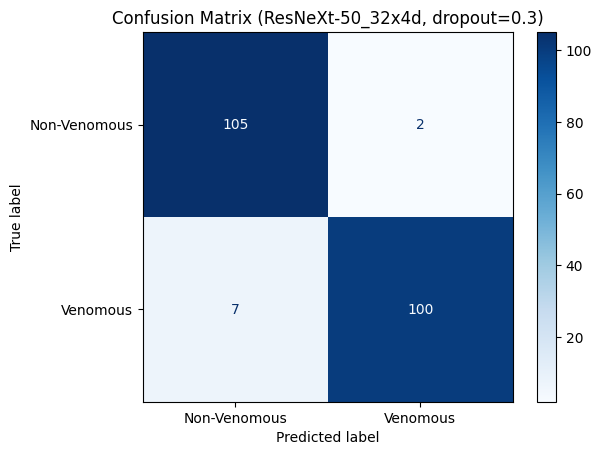


Final model saved as 'final_resnext50_model.pth'
Best model saved as 'best_resnext50_model.pth'
Training complete!


In [1]:
# Installation note: Before running this code, ensure you have the required packages installed:
# pip install torch torchvision torchaudio scikit-learn matplotlib tqdm pandas numpy pillow timm

import os
# Suppress warnings if needed
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, WeightedRandomSampler
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, f1_score
from sklearn.utils.class_weight import compute_class_weight
from tqdm import tqdm
from collections import Counter
import warnings
import timm  # For pretrained models

warnings.filterwarnings('ignore')

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Hyperparameters (kept the same)
image_size = 320
batch_size = 32
num_epochs = 300
learning_rate = 1e-4    # 0.0001
dropout_rate = 0.3

# Define data directories
train_dir = "Dataset_Split/train"
val_dir = "Dataset_Split/val"
test_dir = "Dataset_Split/test"

# Function to get class distribution
def get_class_distribution(data_dir):
    labels = []
    for subfolder in os.listdir(data_dir):
        subfolder_path = os.path.join(data_dir, subfolder)
        if os.path.isdir(subfolder_path):
            num_samples = len([f for f in os.listdir(subfolder_path)
                               if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
            labels.extend([subfolder] * num_samples)
    return Counter(labels)

print("Train class distribution:", get_class_distribution(train_dir))
print("Val class distribution:", get_class_distribution(val_dir))
print("Test class distribution:", get_class_distribution(test_dir))

# Enhanced Transforms (kept the same)
train_transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.RandomRotation(45),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.3),
    transforms.RandomAffine(degrees=0, shear=10),
    transforms.RandomPerspective(distortion_scale=0.2, p=0.3),
    transforms.RandomResizedCrop(image_size, scale=(0.6, 1.2)),
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4, hue=0.15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

test_transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Datasets
train_dataset = ImageFolder(train_dir, transform=train_transform)
val_dataset = ImageFolder(val_dir, transform=test_transform)
test_dataset = ImageFolder(test_dir, transform=test_transform)

# Class weights for loss
class_names = train_dataset.classes
y_train = [label for _, label in train_dataset.samples]
class_weights_np = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = torch.tensor(class_weights_np, dtype=torch.float).to(device)
print("Class weights:", class_weights)

# Weighted sampler for class balancing
sample_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
sample_weights = np.array([sample_weights[label] for _, label in train_dataset.samples])
sampler = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, sampler=sampler,
                          num_workers=4, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False,
                        num_workers=4, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False,
                         num_workers=4, pin_memory=True)

# ────────────────────────────────────────────────────────────────
#       Changed model: resnext50_32x4d instead of convnext_tiny
# ────────────────────────────────────────────────────────────────
print("Loading ResNeXt-50 (32x4d) model...")
model = timm.create_model('resnext50_32x4d',
                          pretrained=True,
                          num_classes=2,
                          drop_rate=dropout_rate)
model = model.to(device)

# Optimizer and loss (unchanged)
optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1, weight=class_weights)

# Learning rate scheduler (unchanged)
from torch.optim.lr_scheduler import CosineAnnealingLR
scheduler = CosineAnnealingLR(optimizer, T_max=num_epochs)

# Early stopping params (unchanged)
patience = 5
best_val_loss = float('inf')
early_stop_counter = 0

# Training history
train_losses, train_accs = [], []
val_losses, val_accs = [], []

print(f"Starting training with pretrained ResNeXt-50_32x4d (dropout={dropout_rate})...")
print(f"Training for {num_epochs} epochs with early stopping (patience={patience})")

for epoch in range(num_epochs):
    # Train
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]"):
        inputs = inputs.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # Gradient clipping
        optimizer.step()
        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc = correct / total
    train_losses.append(train_loss)
    train_accs.append(train_acc)

    scheduler.step()  # Step per epoch

    # Validate
    model.eval()
    val_running_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for inputs, labels in tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Val]"):
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_loss = val_running_loss / len(val_loader)
    val_acc = val_correct / val_total
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    print(f'Epoch {epoch+1}/{num_epochs} - Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, '
          f'Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}')

    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'best_resnext50_model.pth')
        print(f" → Best model saved (val_loss: {val_loss:.4f})")
        early_stop_counter = 0
    else:
        early_stop_counter += 1
        if early_stop_counter >= patience:
            print(f'Early stopping at epoch {epoch+1}')
            break

# Load best model
print("\nLoading best model for evaluation...")
model.load_state_dict(torch.load('best_resnext50_model.pth', map_location=device))

# Evaluate on test set
model.eval()
test_running_loss, test_correct, test_total = 0.0, 0, 0
all_preds, all_labels = [], []

with torch.no_grad():
    for inputs, labels in tqdm(test_loader, desc="Testing"):
        inputs = inputs.to(device)
        labels = labels.to(device)
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        test_running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        test_total += labels.size(0)
        test_correct += (predicted == labels).sum().item()
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_acc = test_correct / test_total
test_f1 = f1_score(all_labels, all_preds, average='weighted')

print(f'\n{"="*50}')
print(f'Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)')
print(f'Test F1-Score: {test_f1:.4f}')
print(f'{"="*50}\n')

# Plot training history
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(train_accs, label='Train', linewidth=2)
plt.plot(val_accs, label='Validation', linewidth=2)
plt.title(f'Model Accuracy (ResNeXt-50_32x4d, dropout={dropout_rate})')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(train_losses, label='Train', linewidth=2)
plt.plot(val_losses, label='Validation', linewidth=2)
plt.title(f'Model Loss (ResNeXt-50_32x4d, dropout={dropout_rate})')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history_resnext50.png', dpi=300, bbox_inches='tight')
plt.show()

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues)
plt.title(f'Confusion Matrix (ResNeXt-50_32x4d, dropout={dropout_rate})')
plt.savefig('confusion_matrix_resnext50.png', dpi=300, bbox_inches='tight')
plt.show()

# Save final model
torch.save(model.state_dict(), 'final_resnext50_model.pth')

print("\nFinal model saved as 'final_resnext50_model.pth'")
print("Best model saved as 'best_resnext50_model.pth'")
print("Training complete!")